## 2D Deconvolution forum question  

Process the image from [this question](https://forum.image.sc/t/limited-improvement-after-2d-psf-deconvolution-on-widefield-images-imagej/1199830) with 2D deconvolution 

## Create an environment and install dependencies

In this environment we will install some tools we need for decon, devbio version of Napari for visualization (which also installs jupyter notebook), sdeconv for theoretical PSF, tnia-python for numpy and cupy deconvolution code and XYZ projected figures in the notebook. 

```
    conda create --name decon-env python=3.9
    conda activate decon-env
    pip install devbio-napari
    pip install git+https://github.com/True-North-Intelligent-Algorithms/tnia-python
    pip install napari-sdeconv
```

In [8]:
import czifile
from tnia.plotting.plt_helper import imshow2d
import numpy as np

im_name = r"/home/bnorthan/images/tnia-python-images/imagesc/2026_03_30_2d_deconvolution_czi/CN500_4_13_11_25_001 (1).czi"

image = czifile.imread(im_name)
image = np.squeeze(image)

print(type(image), print(image.shape), print(image.dtype), print(image.min()), print(image.max()))

waves = ['DAPI', 'FITC', 'Cy5']




(3, 1080, 1920)
uint8
5
255
<class 'numpy.ndarray'> None None None None


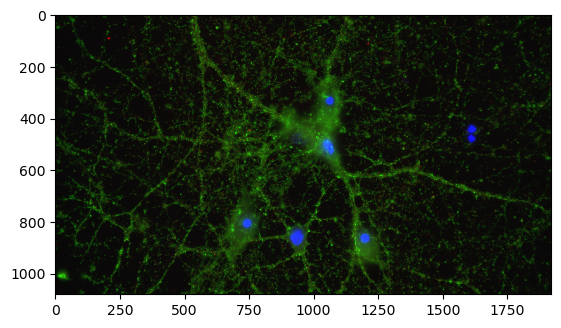

In [9]:
from tnia.plotting.plt_helper import color_dictionary, create_rgb, imshow_multi2d, create_linear_napari_color_map
import matplotlib.pyplot as plt

images = [image[0], image[1], image[2]]

color_image = create_rgb(images, waves, color_dictionary)

plt.imshow(color_image)

## Generate a PSF

I don't know exact values for the acquisition parameters of this image.  Thus I am simply creating a ad-hoc blur function with 'approximately' the blur I see in the image.  

gibson-lanni shape: (33, 33)
gaussian shape: (33, 33)


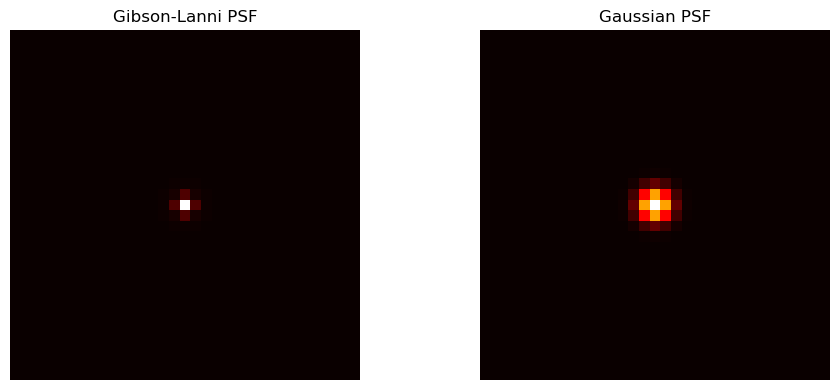

In [10]:
from tnia.deconvolution.psfs import gibson_lanni_3D
from tnia.deconvolution.gaussian_psf import gaussian_2d
import numpy as np
import matplotlib.pyplot as plt

psf_type = 'gibson-lanni'
psf_type = 'gaussian'

xy_psf_dim = 33

NA=1.4
x_voxel_size = .185
z_voxel_size = .185
z_psf_dim=1
ni=1.5
ns=1.4
wavelength = 0.470
defocus = 0

psf_gl  = gibson_lanni_3D(NA, ni, ns, x_voxel_size, z_voxel_size, xy_psf_dim, z_psf_dim, defocus, wavelength, use_psfm=True)
psf_gl = np.squeeze(psf_gl.astype('float32'))
    
psf_gaussian = gaussian_2d(xy_psf_dim, 1)

print('gibson-lanni shape:', psf_gl.shape)
print('gaussian shape:', psf_gaussian.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(psf_gl, cmap='hot')
axes[0].set_title('Gibson-Lanni PSF')
axes[0].axis('off')
axes[1].imshow(psf_gaussian, cmap='hot')
axes[1].set_title('Gaussian PSF')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## Deconvolve the image using either numpy or cupy

Cupy is faster but require Nvidia/Cuda support.  In particular recent Macs do not have Cuda support as they use a custom chip set.  In that case try numpy. 

In [11]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp
from tnia.deconvolution.richardson_lucy_np import richardson_lucy_np
from tnia.deconvolution.decon_helper import create_saturation_mask

import timeit

num_iterations = 100

decons = []

for image in images:
    mask = create_saturation_mask(image)

    start = timeit.default_timer()    
    decon_cp = richardson_lucy_cp(image, psf_gl, num_iterations, mask=mask)
    total = timeit.default_timer() - start
    print('total time: RL CP', total)

    decons.append(decon_cp)


Input size: (1080, 1920), PSF size: (33, 33)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
total time: RL CP 0.3120662698056549
Input size: (1080, 1920), PSF size: (33, 33)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
total time: RL CP 0.2857174598611891
Input size: (1080, 1920), PSF size: (33, 33)
Input is 2D, PSF is 2D

0 10 20 30 40 50 60 70 80 90 
total time: RL CP 0.2856819531880319


In [5]:
import napari

viewer = napari.Viewer()

ind = np.s_[:,:]
for wave, image in zip(waves, images):
#for wave, image in zip(waves, decons_gc):
    color_values = color_dictionary[wave]
    new_colormap = create_linear_napari_color_map(wave, color_values)
    viewer.add_image(image[ind], name=wave, colormap = new_colormap, blending = 'additive')

for wave, decon in zip(waves, decons):
    color_values = color_dictionary[wave]
    new_colormap = create_linear_napari_color_map(wave, color_values)
    viewer.add_image(decon[ind], name='decon '+wave, colormap = new_colormap, blending = 'additive')


## Otsu thresholding

Otsu thresholding is a good way to determine if the deconvolution is actually helpful.  A good deconvolution will improve contrast and lead to better separation of objects after thresholding

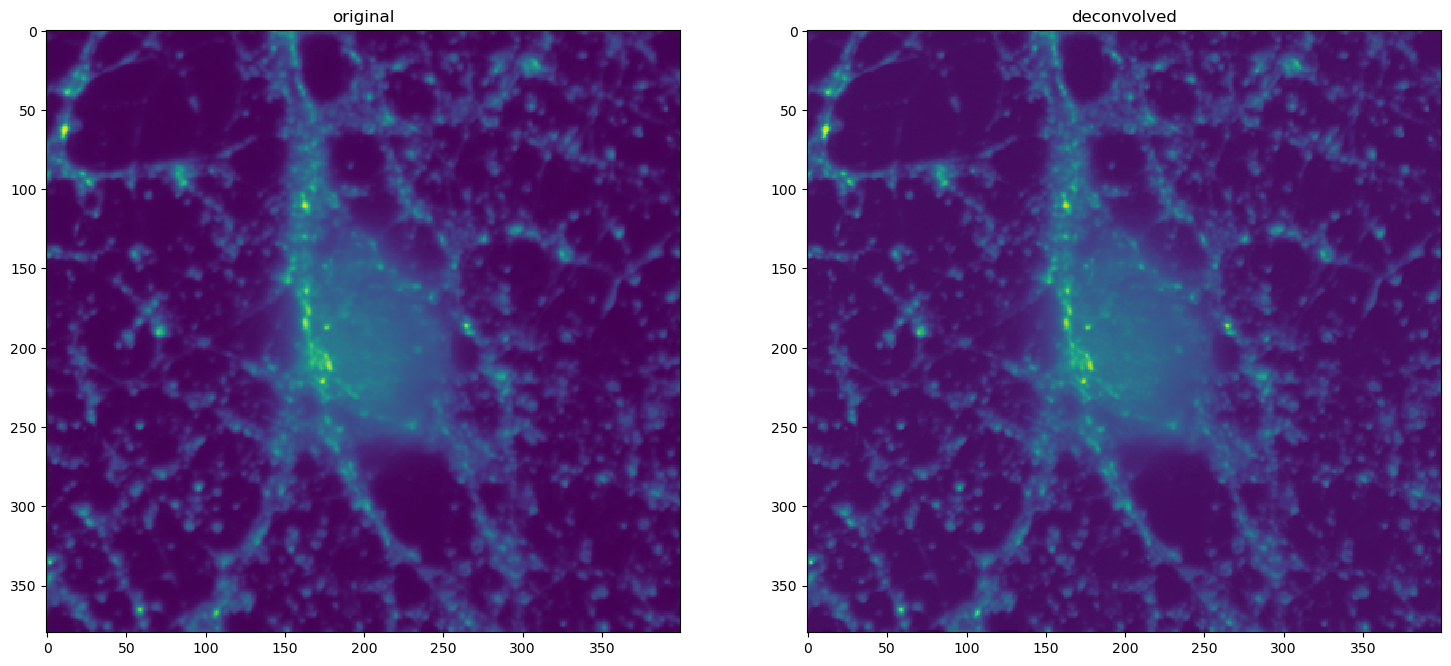

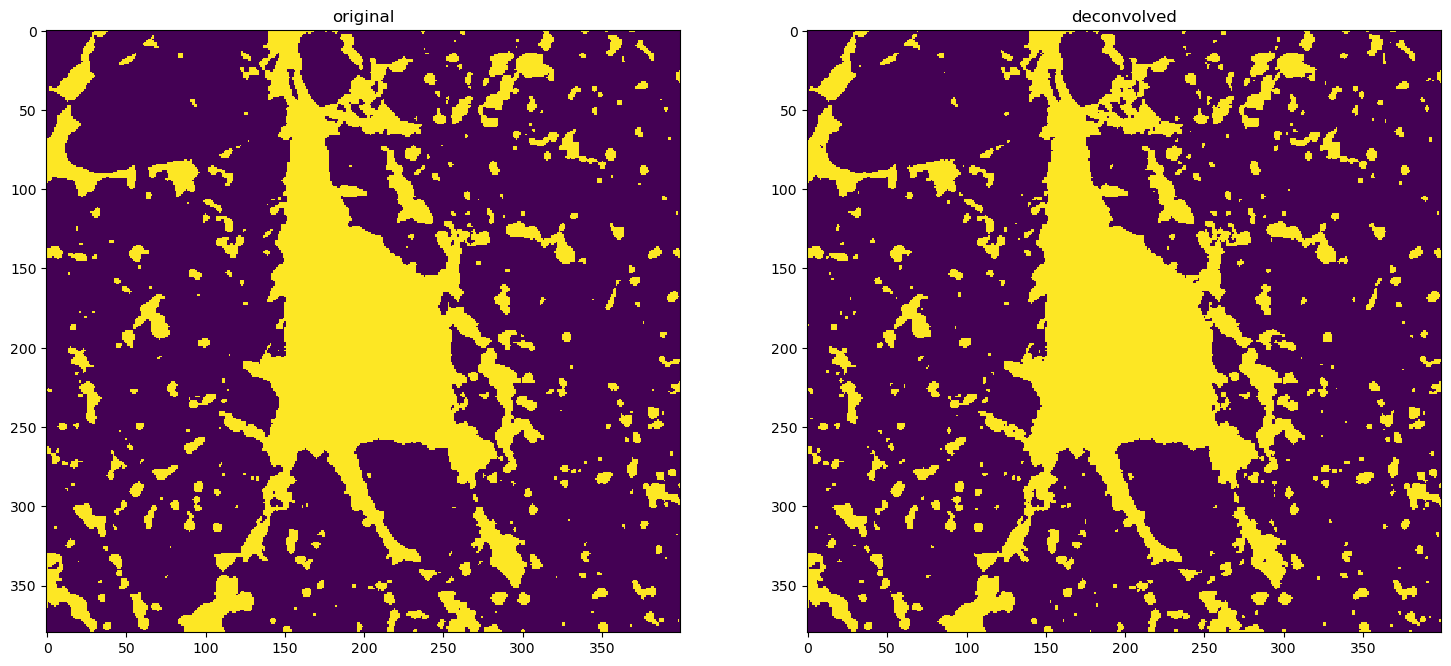

In [12]:
## Otsu threshold on the deconvolved image
from tnia.plotting.plt_helper import imshow_multi2d

ind = np.s_[700:1100, 1000:1400]

im = images[1][ind]
deconvolved = decons[1][ind]

from skimage.filters import threshold_otsu
thresholded = im>threshold_otsu(im)
thresholded_decon = deconvolved>threshold_otsu(deconvolved)

decons = [im, deconvolved]
threshes = [thresholded, thresholded_decon]
titles = ['original', 'deconvolved', 'deconvolved non-circulant']
fig = imshow_multi2d(decons, titles, 1, 2, 18, 8)
fig = imshow_multi2d(threshes, titles, 1, 2, 18, 8)


In [33]:
viewer = napari.Viewer()

viewer.add_image(im, name='original', colormap = 'gray')
viewer.add_labels(thresholded, name='thresholded original')
viewer.add_image(deconvolved, name='deconvolved', colormap = 'gray')
viewer.add_labels(thresholded_decon, name='thresholded deconvolved')

<Labels layer 'thresholded deconvolved' at 0x7c6e2824d760>